In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np

In [2]:
path = r'C:\Users\ross.mckenna\OneDrive - Emirates Group\Cbase Files\EK_spml'

all_files = glob.glob(os.path.join(path, "*.xls"))

df = pd.concat((pd.read_excel(f) for f in all_files), ignore_index=True)

df.dropna(subset=['Flight Date'], inplace=True)

df.sort_values('Flight Date', inplace=True)

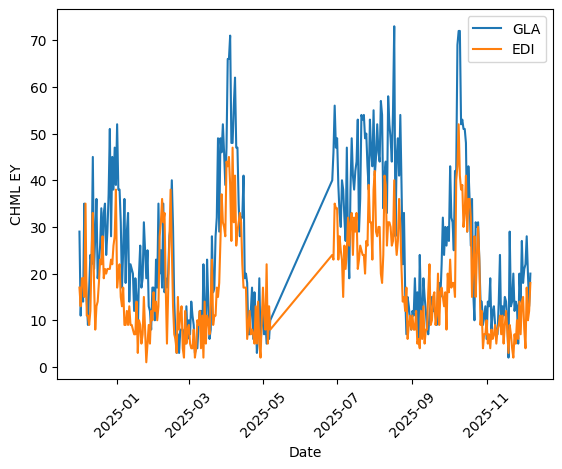

In [3]:
df_ey = df[(df['Class'] == 'EY') & (df['Code'] == 'CHML')]

df_ey_28 = df_ey[df_ey['Flight No.'] == 28].set_index('Flight Date')
df_ey_24 = df_ey[df_ey['Flight No.'] == 24].set_index('Flight Date')

plt.plot(df_ey_28['Qty'], label='GLA')
plt.plot(df_ey_24['Qty'], label='EDI')

plt.xticks(rotation=45)
plt.legend()
plt.ylabel('CHML EY')
plt.xlabel('Date')

plt.show()

## Weekend and Holiday

In [17]:
def get_stats_hol(df, fln):
    holidays_2025 = {
        'Spring_Break': (pd.to_datetime('2025-04-04'), pd.to_datetime('2025-04-22')),
        'Summer_Break': (pd.to_datetime('2025-06-26'), pd.to_datetime('2025-08-13')),
        'Oct_Break': (pd.to_datetime('2025-10-12'), pd.to_datetime('2025-10-19')),
        'Winter_Break': (pd.to_datetime('2025-12-20'), pd.to_datetime('2026-01-05')),
    }

    print(f"Flight No. {fln}")

    holiday_bool = []
    for date in df.index:
        is_holiday = any(start <= date <= end for start, end in holidays_2025.values())
        holiday_bool.append(is_holiday)

    x1 = df[holiday_bool]['Qty']
    print("Holiday")
    print(x1.describe())
    print("")

    x2 = df[[not elem for elem in holiday_bool]]['Qty']
    print("Not Holiday")
    print(x2.describe())
    print("")

    fig, (ax1,ax2) = plt.subplots(2, 1)
    ax1.hist(x1, bins =10)
    ax1.set_title("Holiday")
    ax2.hist(x2, bins =10)
    ax2.set_title("Not Holiday")
    ax2.sharey(ax1)
    ax2.sharex(ax1)

    for ax in fig.get_axes():
        ax.label_outer()
    
    plt.show()

Flight No. 24
Holiday
count    75.000000
mean     27.586667
std       8.394164
min       6.000000
25%      23.000000
50%      28.000000
75%      32.500000
max      47.000000
Name: Qty, dtype: float64

Not Holiday
count    247.000000
mean      14.680162
std        9.756326
min        1.000000
25%        8.000000
50%       12.000000
75%       19.000000
max       52.000000
Name: Qty, dtype: float64



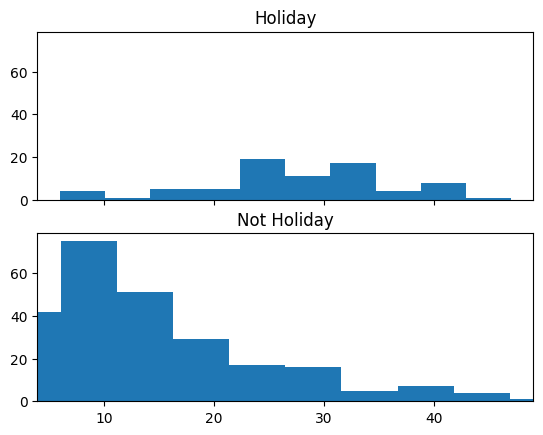

In [18]:
get_stats_hol(df_ey_24, 24)

Flight No. 28
Holiday
count    75.000000
mean     40.826667
std      12.834048
min       7.000000
25%      33.000000
50%      43.000000
75%      49.500000
max      71.000000
Name: Qty, dtype: float64

Not Holiday
count    246.000000
mean      21.642276
std       14.487788
min        2.000000
25%       11.000000
50%       17.000000
75%       29.000000
max       73.000000
Name: Qty, dtype: float64



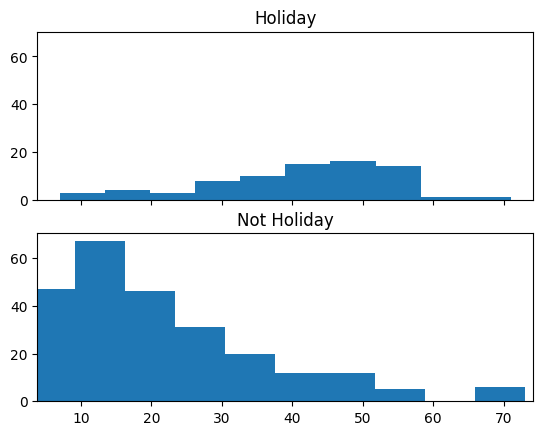

In [19]:
get_stats_hol(df_ey_28, 28)